# Auditing a Model You Did Not Intend to Be Unfair

**Session 30 · no homework grades this · the capstone's model card needs it**

The model in this notebook never sees the sensitive attribute. It is trained on
ordinary features by ordinary code, and it still produces materially different
error rates for two groups — because one of its features carries the group
information anyway.

That is the normal case, not the pathological one. So the work is: measure the
disparity, understand why two reasonable definitions of "fair" cannot both be
satisfied, and read an explanation for what it is — a statement about the model,
not about the world.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import shap
import lime
import lime.lime_tabular
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

print("scikit-learn", sklearn.__version__)
print("shap        ", shap.__version__)
print("lime        ", lime.__version__ if hasattr(lime, "__version__") else "installed")

rng = np.random.default_rng(30)
n = 6000

# The sensitive attribute. The model will never be given this column.
group = rng.choice(["A", "B"], n, p=[0.7, 0.3])
is_b = (group == "B")

# A proxy: postcode differs by group. Nobody wrote that rule; it is how the
# neighbourhoods are.
postcode = np.where(is_b, rng.normal(2.0, 1.0, n), rng.normal(0.0, 1.0, n))

# Genuine, group-independent predictors.
history = rng.normal(0, 1, n)
ratio = rng.normal(0, 1, n)

# The outcome depends on the real predictors AND slightly on the postcode --
# because the neighbourhood really does carry some signal. Both facts are true.
logit = 1.3 * history + 0.9 * ratio + 0.35 * postcode + rng.normal(0, 1.0, n)
repaid = (logit > np.median(logit)).astype(int)

features = pd.DataFrame({"history": history, "ratio": ratio, "postcode": postcode})
print(f"\nbase rate overall {repaid.mean():.3f}")
print(f"  group A {repaid[~is_b].mean():.3f}   group B {repaid[is_b].mean():.3f}")
print(f"correlation between postcode and group: "
      f"{np.corrcoef(postcode, is_b.astype(float))[0, 1]:.3f}")

scikit-learn 1.7.2
shap         0.52.0
lime         installed

base rate overall 0.500
  group A 0.453   group B 0.604
correlation between postcode and group: 0.680


Note what has already happened, before any model exists: the two groups have
different base rates, and one feature is strongly correlated with group
membership. Dropping the sensitive attribute — which we are about to do — does
not remove either fact.

## 1. Train, without the sensitive attribute

In [2]:
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    features, repaid, group, test_size=0.35, random_state=0, stratify=repaid)

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                               random_state=0, n_jobs=-1).fit(X_train, y_train)
scores = model.predict_proba(X_test)[:, 1]
predicted = (scores >= 0.5).astype(int)

print("columns the model saw:", list(X_train.columns))
print(f"overall test accuracy: {(predicted == y_test).mean():.3f}")

columns the model saw: ['history', 'ratio', 'postcode']
overall test accuracy: 0.839


## 2. The audit: four rates, per group, with intervals

A single number per group is not a finding. Bootstrap the interval, because a
gap of two points on ninety rows means nothing.

In [3]:
def rates(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    return {
        "selection rate": (tp + fp) / len(y_true),
        "TPR": tp / (tp + fn) if tp + fn else np.nan,
        "FPR": fp / (fp + tn) if fp + tn else np.nan,
        "PPV": tp / (tp + fp) if tp + fp else np.nan,
    }


def interval(y_true, y_pred, metric, draws=400, seed=0):
    boot = np.random.default_rng(seed)
    values = []
    for _ in range(draws):
        idx = boot.integers(0, len(y_true), len(y_true))
        values.append(rates(y_true[idx], y_pred[idx])[metric])
    return np.nanpercentile(values, [2.5, 97.5])


rows = []
for name in ("A", "B"):
    mask = g_test == name
    r = rates(y_test[mask], predicted[mask])
    row = {"group": name, "n": int(mask.sum())}
    for metric, value in r.items():
        low, high = interval(y_test[mask], predicted[mask], metric, seed=hash(name) % 1000)
        row[metric] = f"{value:.3f}  [{low:.3f}, {high:.3f}]"
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

group    n        selection rate                   TPR                   FPR                   PPV
    A 1456 0.475  [0.450, 0.499] 0.838  [0.813, 0.868] 0.173  [0.147, 0.200] 0.802  [0.770, 0.830]
    B  644 0.595  [0.561, 0.632] 0.871  [0.840, 0.905] 0.176  [0.131, 0.226] 0.883  [0.851, 0.915]


In [4]:
gaps = {}
for metric in ("selection rate", "TPR", "FPR", "PPV"):
    a = rates(y_test[g_test == "A"], predicted[g_test == "A"])[metric]
    b = rates(y_test[g_test == "B"], predicted[g_test == "B"])[metric]
    gaps[metric] = b - a
    print(f"{metric:<15} A {a:.3f}   B {b:.3f}   difference {b - a:+.3f}")

print(f"\ndisparate impact ratio (selection rate B / A): "
      f"{rates(y_test[g_test == 'B'], predicted[g_test == 'B'])['selection rate'] / rates(y_test[g_test == 'A'], predicted[g_test == 'A'])['selection rate']:.3f}")

selection rate  A 0.475   B 0.595   difference +0.119
TPR             A 0.838   B 0.871   difference +0.033
FPR             A 0.173   B 0.176   difference +0.003
PPV             A 0.802   B 0.883   difference +0.080

disparate impact ratio (selection rate B / A): 1.251


The four criteria correspond to four different definitions of fairness, and they
are not compatible:

| Criterion | Requires | Called |
|---|---|---|
| selection rate | equal across groups | demographic parity |
| TPR (and FPR) | equal across groups | equalised odds |
| PPV | equal across groups | predictive parity |

**When the base rates differ, you cannot have all of them.** That is a theorem,
not a limitation of this model or this notebook: for any classifier that is not
perfect, equal PPV and equal FPR across groups with unequal base rates is
arithmetically impossible. Choosing a fairness criterion is therefore a
statement about which harm you are prioritising, and it belongs in the model
card next to the number.

## 3. Trying to fix it with a threshold

Group-specific thresholds can equalise one criterion exactly. Watch what it
costs on the others.

In [5]:
def threshold_for(target_rate, mask):
    return float(np.quantile(scores[mask], 1 - target_rate))

overall_rate = predicted.mean()
adjusted = predicted.copy()
for name in ("A", "B"):
    mask = g_test == name
    adjusted[mask] = (scores[mask] >= threshold_for(overall_rate, mask)).astype(int)

print("after equalising selection rates by group:\n")
comparison = []
for name in ("A", "B"):
    mask = g_test == name
    before = rates(y_test[mask], predicted[mask])
    after = rates(y_test[mask], adjusted[mask])
    comparison.append({"group": name,
                       **{f"{k} before": round(v, 3) for k, v in before.items()},
                       **{f"{k} after": round(v, 3) for k, v in after.items()}})
table = pd.DataFrame(comparison).set_index("group")
print(table[[c for c in table.columns if "selection" in c or "PPV" in c]].to_string())
print(f"\noverall accuracy before {(predicted == y_test).mean():.3f}"
      f"   after {(adjusted == y_test).mean():.3f}")

after equalising selection rates by group:

       selection rate before  PPV before  selection rate after  PPV after
group                                                                    
A                      0.475       0.802                 0.512      0.769
B                      0.595       0.883                 0.512      0.915

overall accuracy before 0.839   after 0.821


Selection rates now match. PPV has moved apart, and overall accuracy has fallen
— the applicants who changed sides were, on average, the ones the model was
least sure about.

Nothing here is a solution. It is a menu of trade-offs, and the deliverable is a
sentence in the model card saying which one was chosen and who bears the cost.

## 4. Where the model is getting the group information

The audit says there is a disparity. SHAP says which feature carries it.

In [6]:
explainer = shap.TreeExplainer(model)
sample = X_test.iloc[:600]
shap_values = explainer.shap_values(sample, check_additivity=False)

# For a binary forest, shap_values has shape (rows, features, classes)
positive = shap_values[..., 1] if shap_values.ndim == 3 else shap_values
mean_abs = np.abs(positive).mean(axis=0)

print("mean |SHAP value| per feature (contribution to P(repaid)):")
for name, value in sorted(zip(sample.columns, mean_abs), key=lambda p: -p[1]):
    print(f"  {name:<10} {value:.4f}")

mean |SHAP value| per feature (contribution to P(repaid)):
  history    0.2371
  ratio      0.1582
  postcode   0.0842


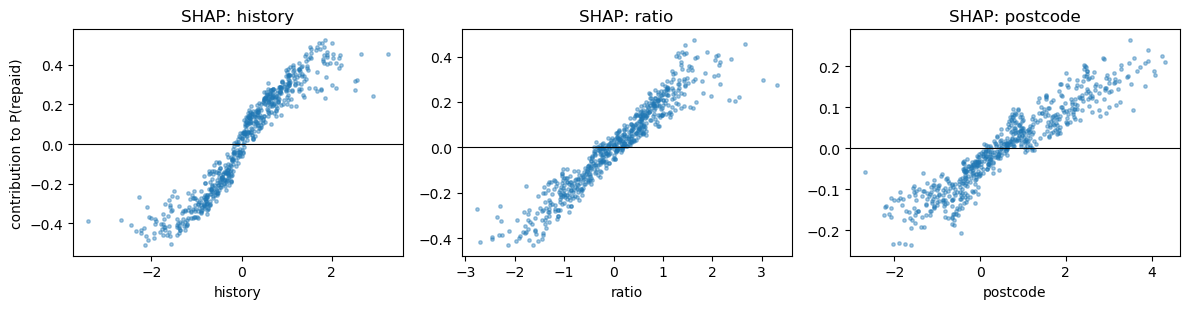

In [7]:
order = np.argsort(mean_abs)[::-1]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, j in zip(axes, order):
    ax.scatter(sample.iloc[:, j], positive[:, j], s=6, alpha=.4)
    ax.axhline(0, color="black", lw=.8)
    ax.set_xlabel(sample.columns[j]); ax.set_title(f"SHAP: {sample.columns[j]}")
axes[0].set_ylabel("contribution to P(repaid)")
plt.tight_layout(); plt.show()

`postcode` carries real weight, and `postcode` is the proxy. That is the audit's
answer to "where did the disparity come from" — and it is an answer about the
*model*, not about neighbourhoods, and certainly not about the people who live
in them.

## 5. One decision, explained two ways

LIME fits a simple local model around a single instance. It answers a different
question from SHAP's, and the two do not have to agree — which is worth seeing
once, on the same row.

In [8]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=list(X_train.columns),
    class_names=["denied", "repaid"], discretize_continuous=True, random_state=0)

i = int(np.argmin(np.abs(scores - 0.5)))     # the most borderline decision
row = X_test.iloc[i]
print(f"row {i}: {row.round(3).to_dict()}")
print(f"model P(repaid) = {scores[i]:.3f}   true outcome = {y_test[i]}   "
      f"group = {g_test[i]}\n")

# LIME hands the model bare arrays; wrap so the forest still sees its columns.
predict_frame = lambda a: model.predict_proba(pd.DataFrame(a, columns=X_train.columns))

lime_result = lime_explainer.explain_instance(row.values, predict_frame, num_features=3)
print("LIME, local to this row:")
for feature, weight in lime_result.as_list():
    print(f"  {feature:<28} {weight:+.4f}")

print("\nSHAP, same row:")
single = explainer.shap_values(X_test.iloc[[i]], check_additivity=False)
single = single[..., 1] if single.ndim == 3 else single
for name, value in zip(X_test.columns, single[0]):
    print(f"  {name:<28} {value:+.4f}")

row 1162: {'history': 0.054, 'ratio': 0.169, 'postcode': -0.065}
model P(repaid) = 0.500   true outcome = 1   group = A

LIME, local to this row:
  0.01 < history <= 0.69       +0.1855
  -0.02 < ratio <= 0.67        +0.0742
  -0.35 < postcode <= 0.53     -0.0454

SHAP, same row:
  history                      +0.0464
  ratio                        +0.0207
  postcode                     -0.0674


Two explanations of one decision, in different units: SHAP's values are additive
contributions to the prediction and sum to the gap from the base value; LIME's
are coefficients of a local surrogate fitted to perturbed samples, and depend on
how the perturbations were drawn.

**What neither one is:**

- not a causal claim — nothing here says changing the postcode would change the
  outcome, only that the model's output depends on it;
- not stable under refitting — retrain the forest with a different seed and the
  attributions move;
- not a defence — "the model explained itself" is not evidence that the decision
  was correct or lawful.

## 6. What goes in the model card

In [9]:
card = f'''
## Fairness and limitations

Sensitive attribute: group membership (A/B), NOT used as a feature.
Proxy identified: `postcode`, correlated with group at r = {np.corrcoef(postcode, is_b.astype(float))[0, 1]:.2f}.

Measured on {len(y_test)} held-out rows, threshold 0.5:

  selection rate   A {rates(y_test[g_test == "A"], predicted[g_test == "A"])["selection rate"]:.3f}   B {rates(y_test[g_test == "B"], predicted[g_test == "B"])["selection rate"]:.3f}
  TPR              A {rates(y_test[g_test == "A"], predicted[g_test == "A"])["TPR"]:.3f}   B {rates(y_test[g_test == "B"], predicted[g_test == "B"])["TPR"]:.3f}
  FPR              A {rates(y_test[g_test == "A"], predicted[g_test == "A"])["FPR"]:.3f}   B {rates(y_test[g_test == "B"], predicted[g_test == "B"])["FPR"]:.3f}
  PPV              A {rates(y_test[g_test == "A"], predicted[g_test == "A"])["PPV"]:.3f}   B {rates(y_test[g_test == "B"], predicted[g_test == "B"])["PPV"]:.3f}

Criterion chosen: equalised selection rate, at a cost of
{(predicted == y_test).mean() - (adjusted == y_test).mean():.3f} overall accuracy and a widened PPV gap.
Who bears the cost: applicants near the threshold in group A.

Not established: any causal claim about postcode; stability of attributions
under refitting; behaviour on populations unlike this sample.
'''
print(card)


## Fairness and limitations

Sensitive attribute: group membership (A/B), NOT used as a feature.
Proxy identified: `postcode`, correlated with group at r = 0.68.

Measured on 2100 held-out rows, threshold 0.5:

  selection rate   A 0.475   B 0.595
  TPR              A 0.838   B 0.871
  FPR              A 0.173   B 0.176
  PPV              A 0.802   B 0.883

Criterion chosen: equalised selection rate, at a cost of
0.017 overall accuracy and a widened PPV gap.
Who bears the cost: applicants near the threshold in group A.

Not established: any causal claim about postcode; stability of attributions
under refitting; behaviour on populations unlike this sample.



## A note on the data you audit with

This audit needs the sensitive attribute even though the model does not. That is
the standard tension: you cannot measure a disparity you refuse to record.

Collect and use such attributes only where it is lawful, consented, secured, and
governed — for auditing, not for scoring — and say in the model card that this
is what you did.

## What to take from this

- Removing the sensitive attribute does not remove the disparity; proxies carry
  it. Audit the outcome, not the feature list.
- Report group-wise selection rate, TPR, FPR and PPV **with intervals**.
- The fairness criteria are mutually incompatible when base rates differ.
  Choosing one is a value judgement, and it belongs in writing.
- A threshold adjustment moves the harm; it does not remove it.
- SHAP and LIME explain the model. They are not causal, not stable, and not a
  defence.

## Where to go next

- **Reading, Session 30** — the fairness definitions, SHAP, LIME, and model
  cards in full.
- **Depth page: fairness mitigation and governance** — the methods this session
  does not have time for.
- **The capstone** — run this audit on your own model and paste the card.